# Imports and Styling

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
from scipy import stats
import utils
import seaborn as sns
import pingouin as pg
import matplotlib.cm as cm

import statsmodels.stats.power as smp
from statsmodels.stats.anova import AnovaRM
from tqdm import tqdm


from natsort import index_natsorted

# plt.rcParams['font.family'] = 'Times New Roman'
# plt.rcParams['font.family'] = 'Calibri'

path_figs = "./Figs/"

seq_length = 11 #Length of sequences

fingers = ['1', '2', '3', '4', '5'] #mapping of fingers to numbers

iti = 3000   #Inter trial interval
hand = 2 #left or right hand

sub_nums = [5, 6, 7, 8, 9, 10, 12, 13]
sub_nums = [10, 12, 13, 14, 15, 16, 17] # with feedbacks

# total_sub_num = 38
num_sessions = 1
num_blocks_per_session = 12
num_baseline_blocks = 1


In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.ticker as ticker

def set_figure_style(scale="1col"):
    """
    Set figure styling based on publication constraints.
    
    Parameters:
        scale (str): Scale of the figure, choose from "1col", "1.5col", "2col".
                     - "1col" for 8.5cm
                     - "1.5col" for 11.6cm
                     - "2col" for 17.6cm
    """
    # Define width options in cm
    widths = {"1col": 7.62, "1.5col": 11.6, "2col": 16.5}
    
    if scale not in widths:
        raise ValueError("Invalid scale. Choose from '1col', '1.5col', or '2col'.")
    
    # Convert width from cm to inches (1 cm = 0.393701 inches)
    width_in = widths[scale] * 0.393701
    
    # Set figure size (width, height)
    # Assuming height proportional to width (Golden Ratio)
    golden_ratio = (5**0.5 - 1) / 2
    rcParams["figure.figsize"] = (width_in, width_in * golden_ratio)
    
    # Set font sizes
    rcParams["font.size"] = 10  # General font size
    rcParams["axes.titlesize"] = 12  # Figure title
    rcParams["axes.labelsize"] = 9  # Axis main label
    rcParams["xtick.labelsize"] = 7  # Tick labels
    rcParams["ytick.labelsize"] = 7
    rcParams["legend.fontsize"] = 8  # Legend entries
    rcParams["figure.titleweight"] = "bold"
    
    # Set stroke width
    rcParams["axes.linewidth"] = 0.75
    rcParams["xtick.major.width"] = 0.75
    rcParams["ytick.major.width"] = 0.75

    
    # Subpanel lettering size
    rcParams["text.usetex"] = False  # Set to True if using LaTeX
    rcParams["axes.formatter.use_mathtext"] = True  # Math text for scientific notation

def add_subpanel_label(ax, label, fontsize=20, position=(-0.1, 1.05)):
    """
    Add a subpanel label (e.g., 'a', 'b') to a subplot.
    
    Parameters:
        ax (Axes): Matplotlib Axes object.
        label (str): The label text.
        fontsize (int): Font size for the label.
        position (tuple): Position of the label in axes coordinates.
    """
    ax.text(position[0], position[1], label, transform=ax.transAxes, 
            fontsize=fontsize, fontweight="bold", va="top", ha="left")

###
set_figure_style(scale="1col")

sns.color_palette('colorblind')


[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

# dat processing

In [3]:
subjs_list = utils.read_dat_files_subjs_list(sub_nums)

for subj in subjs_list: ###Adding IPIs
    utils.add_IPI(subj)


subjs = pd.concat(subjs_list) ###Merging all subjs into one dataframe
# exclude first familiarization block
subjs = subjs[subjs['BN'] != 1]
subjs['isTrainSeq'] = subjs.apply(utils.add_trained_transfer_untrained_flag, axis=1)
subjs['effector+isTrain'] = subjs['effector'].astype(str) + '_' + subjs['isTrainSeq'].astype(str)
subjs['isPrePostTrain'] = subjs.apply(utils.add_pre_train_post_flag, axis=1)
subjs.reset_index(inplace=True, drop=True)
subjs['count'] = 1

# Speech (Raw)

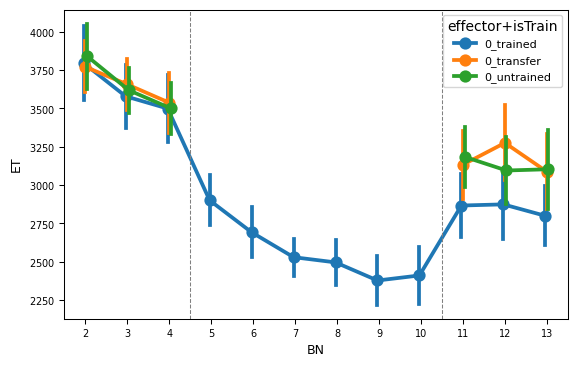

In [4]:
set_figure_style(scale="2col")
subjs_correct = subjs[subjs['isError'] == 0]
subjs_grouped = subjs_correct.groupby(['SubNum', 'BN', 'effector+isTrain', 'effector']).agg({
    'ET': 'median',
    'count': 'sum'
}).reset_index()

# effector = speech (0)
subjs_grouped = subjs_grouped[subjs_grouped['effector'] == 0]

sns.pointplot(data=subjs_grouped, x='BN', y='ET', hue='effector+isTrain', dodge = True, errorbar = 'se')
plt.axvline(x=2.5, color='gray', linestyle='--', linewidth=0.75)
plt.axvline(x=8.5, color='gray', linestyle='--', linewidth=0.75)

Trained vs Transfer: TtestResult(statistic=2.5453350576527614, pvalue=0.04376493600750481, df=6)
Trained vs Untrained: TtestResult(statistic=2.7216983883660997, pvalue=0.034564743858029046, df=6)
Transfer vs Untrained: TtestResult(statistic=-0.976781773503471, pvalue=0.3664001691067401, df=6)


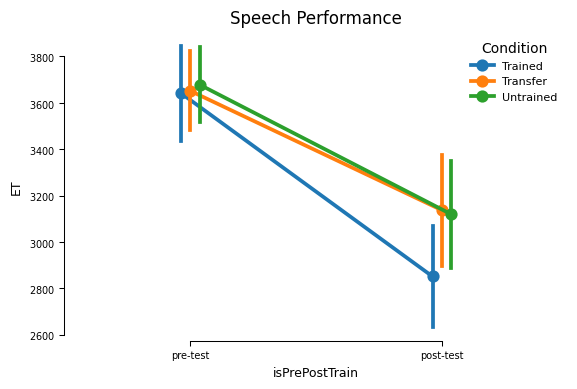

In [5]:
set_figure_style(scale="2col")

subjs_correct = subjs[subjs['isError'] == 0]
subjs_grouped = subjs_correct.groupby(['isPrePostTrain', 'SubNum', 'effector+isTrain', 'effector']).agg({
    'ET': 'median',
    'count': 'sum'
}).reset_index()

subjs_grouped = subjs_grouped[subjs_grouped['isPrePostTrain'] != 'train']
subjs_grouped = subjs_grouped[subjs_grouped['effector'] == 0]

subjs_grouped['isPrePostTrain'] = pd.Categorical(
    subjs_grouped['isPrePostTrain'],
    categories=['pre-test', 'post-test'],
    ordered=True
)

hue_order = ['0_trained', '0_transfer', '0_untrained']
label_map = {
    '0_trained': 'Trained',
    '0_transfer': 'Transfer',
    '0_untrained': 'Untrained'
}

ax = sns.pointplot(
    data=subjs_grouped,
    x='isPrePostTrain',
    y='ET',
    hue='effector+isTrain',
    hue_order=hue_order,
    dodge=True,
    errorbar='se'
)


handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=[label_map.get(l, l) for l in labels],
    title='Condition',
    frameon=False
)
plt.title('Speech Performance')
sns.despine(trim=True)

### statistical analysis
subjs_changes = subjs_grouped.pivot(index = ['SubNum', 'effector+isTrain'], columns='isPrePostTrain', values='ET').reset_index()
subjs_changes['change'] = subjs_changes['pre-test'] - subjs_changes['post-test']

trained_changes = subjs_changes[subjs_changes['effector+isTrain'] == '0_trained']['change']
transfer_changes = subjs_changes[subjs_changes['effector+isTrain'] == '0_transfer']['change']
untrained_changes = subjs_changes[subjs_changes['effector+isTrain'] == '0_untrained']['change']

# Paired t-tests
print("Trained vs Transfer:", stats.ttest_rel(trained_changes, transfer_changes))
print("Trained vs Untrained:", stats.ttest_rel(trained_changes, untrained_changes))
print("Transfer vs Untrained:", stats.ttest_rel(transfer_changes, untrained_changes))



# fingers 

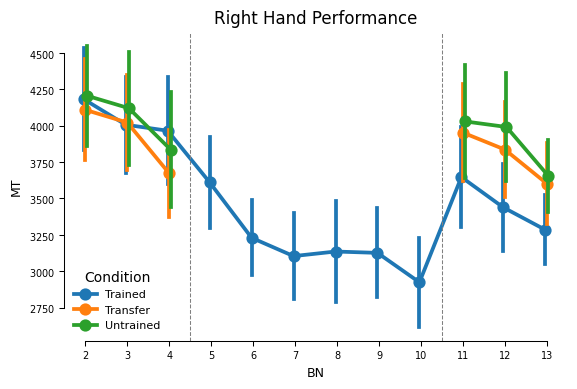

In [6]:
set_figure_style(scale="2col")

subjs_correct = subjs[subjs['isError'] == 0]
subjs_grouped = subjs_correct.groupby(['BN', 'SubNum', 'effector+isTrain', 'effector']).agg({
    'MT': 'median',
    'count': 'sum'
}).reset_index()


# effector = finger (2)
subjs_grouped = subjs_grouped[subjs_grouped['effector'] == 2]

hue_order = ['2_trained', '2_transfer', '2_untrained']
label_map = {
    '2_trained': 'Trained',
    '2_untrained': 'Untrained',
    '2_transfer': 'Transfer'
}

ax = sns.pointplot(
    data=subjs_grouped,
    x='BN', y='MT',
    hue='effector+isTrain',
    hue_order=hue_order,
    dodge=True,
    errorbar='se'
)

plt.axvline(x=2.5, color='gray', linestyle='--', linewidth=0.75)
plt.axvline(x=8.5, color='gray', linestyle='--', linewidth=0.75)


handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    [label_map.get(l, l) for l in labels],
    title='Condition',
    frameon=False
)

plt.title('Right Hand Performance')
sns.despine(trim=True)


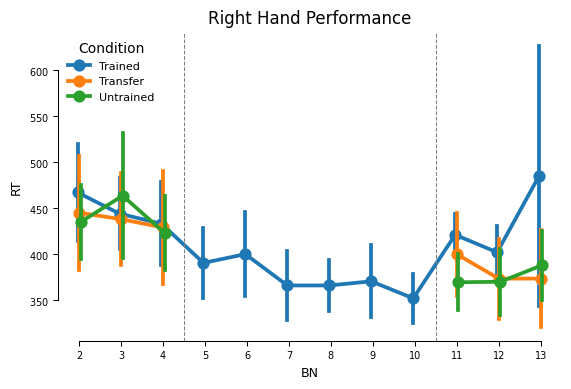

In [14]:
set_figure_style(scale="2col")

subjs_correct = subjs[subjs['isError'] == 0]
subjs_grouped = subjs_correct.groupby(['BN', 'SubNum', 'effector+isTrain', 'effector']).agg({
    'RT': 'median',
    'count': 'sum'
}).reset_index()

# effector = finger (2)
subjs_grouped = subjs_grouped[subjs_grouped['effector'] == 2]

hue_order = ['2_trained', '2_transfer', '2_untrained']
label_map = {
    '2_trained': 'Trained',
    '2_untrained': 'Untrained',
    '2_transfer': 'Transfer'
}

ax = sns.pointplot(
    data=subjs_grouped,
    x='BN', y='RT',
    hue='effector+isTrain',
    hue_order=hue_order,
    dodge=True,
    errorbar='se'
)

plt.axvline(x=2.5, color='gray', linestyle='--', linewidth=0.75)
plt.axvline(x=8.5, color='gray', linestyle='--', linewidth=0.75)


handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    [label_map.get(l, l) for l in labels],
    title='Condition',
    frameon=False
)

plt.title('Right Hand Performance')
sns.despine(trim=True)


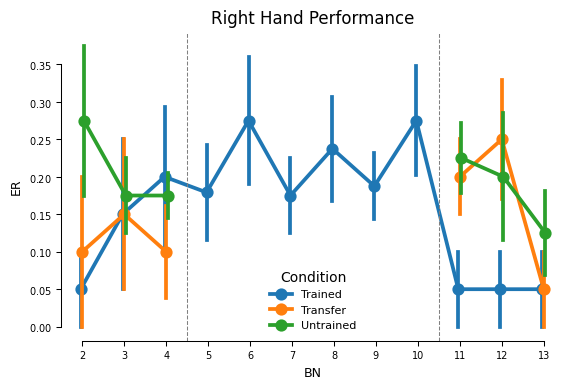

In [15]:
set_figure_style(scale="2col")

# subjs_correct = subjs[subjs['isError'] == 0]
subjs_grouped = subjs.groupby(['BN', 'SubNum', 'effector+isTrain', 'effector']).agg({
    'isError': 'sum',
    'count': 'sum'
}).reset_index()

# effector = finger (2)
subjs_grouped = subjs_grouped[subjs_grouped['effector'] == 2]
subjs_grouped['ER'] = subjs_grouped['isError'] / subjs_grouped['count']

hue_order = ['2_trained', '2_transfer', '2_untrained']
label_map = {
    '2_trained': 'Trained',
    '2_untrained': 'Untrained',
    '2_transfer': 'Transfer'
}

ax = sns.pointplot(
    data=subjs_grouped,
    x='BN', y='ER',
    hue='effector+isTrain',
    hue_order=hue_order,
    dodge=True,
    errorbar='se'
)

plt.axvline(x=2.5, color='gray', linestyle='--', linewidth=0.75)
plt.axvline(x=8.5, color='gray', linestyle='--', linewidth=0.75)


handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles,
    [label_map.get(l, l) for l in labels],
    title='Condition',
    frameon=False
)

plt.title('Right Hand Performance')
sns.despine(trim=True)


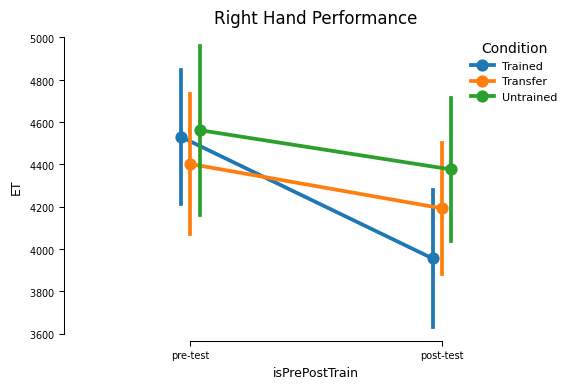

In [7]:
set_figure_style(scale="2col")

subjs_correct = subjs[subjs['isError'] == 0]
subjs_grouped = subjs_correct.groupby(['isPrePostTrain', 'SubNum', 'effector+isTrain', 'effector']).agg({
    'ET': 'median',
    'count': 'sum'
}).reset_index()

subjs_grouped = subjs_grouped[subjs_grouped['isPrePostTrain'] != 'train']
subjs_grouped = subjs_grouped[subjs_grouped['effector'] == 2]

subjs_grouped['isPrePostTrain'] = pd.Categorical(
    subjs_grouped['isPrePostTrain'],
    categories=['pre-test', 'post-test'],
    ordered=True
)

hue_order = ['2_trained', '2_transfer', '2_untrained']
label_map = {
    '2_trained': 'Trained',
    '2_transfer': 'Transfer',
    '2_untrained': 'Untrained'
}

ax = sns.pointplot(
    data=subjs_grouped,
    x='isPrePostTrain',
    y='ET',
    hue='effector+isTrain',
    hue_order=hue_order,
    dodge=True,
    errorbar='se'
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=[label_map.get(l, l) for l in labels],
    title='Condition',
    frameon=False
)
plt.title('Right Hand Performance')
sns.despine(trim=True)


Trained vs Transfer: TtestResult(statistic=1.995585450424257, pvalue=0.09299344328590907, df=6)
Trained vs Untrained: TtestResult(statistic=2.7754796753414617, pvalue=0.03218858536416473, df=6)
Transfer vs Untrained: TtestResult(statistic=0.436834553685473, pvalue=0.6775139741835619, df=6)


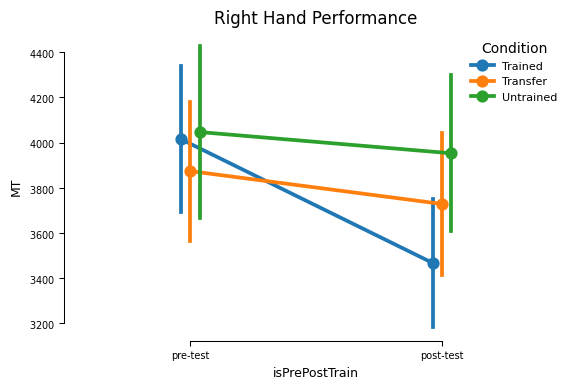

In [8]:
set_figure_style(scale="2col")

subjs_correct = subjs[subjs['isError'] == 0]
subjs_grouped = subjs_correct.groupby(['isPrePostTrain', 'SubNum', 'effector+isTrain', 'effector']).agg({
    'MT': 'median',
    'count': 'sum'
}).reset_index()

subjs_grouped = subjs_grouped[subjs_grouped['isPrePostTrain'] != 'train']
subjs_grouped = subjs_grouped[subjs_grouped['effector'] == 2]

subjs_grouped['isPrePostTrain'] = pd.Categorical(
    subjs_grouped['isPrePostTrain'],
    categories=['pre-test', 'post-test'],
    ordered=True
)

hue_order = ['2_trained', '2_transfer', '2_untrained']
label_map = {
    '2_trained': 'Trained',
    '2_transfer': 'Transfer',
    '2_untrained': 'Untrained'
}

ax = sns.pointplot(
    data=subjs_grouped,
    x='isPrePostTrain',
    y='MT',
    hue='effector+isTrain',
    hue_order=hue_order,
    dodge=True,
    errorbar='se'
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=[label_map.get(l, l) for l in labels],
    title='Condition',
    frameon=False
)
plt.title('Right Hand Performance')
sns.despine(trim=True)


### statistical analysis
subjs_changes = subjs_grouped.pivot(index = ['SubNum', 'effector+isTrain'], columns='isPrePostTrain', values='MT').reset_index()
subjs_changes['change'] = subjs_changes['pre-test'] - subjs_changes['post-test']

trained_changes = subjs_changes[subjs_changes['effector+isTrain'] == '2_trained']['change']
transfer_changes = subjs_changes[subjs_changes['effector+isTrain'] == '2_transfer']['change']
untrained_changes = subjs_changes[subjs_changes['effector+isTrain'] == '2_untrained']['change']

# Paired t-tests
print("Trained vs Transfer:", stats.ttest_rel(trained_changes, transfer_changes))
print("Trained vs Untrained:", stats.ttest_rel(trained_changes, untrained_changes))
print("Transfer vs Untrained:", stats.ttest_rel(transfer_changes, untrained_changes))


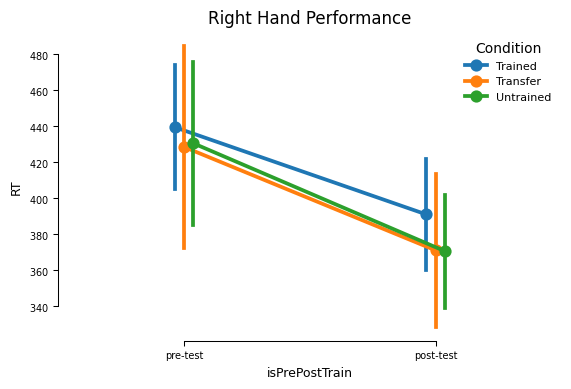

In [21]:
set_figure_style(scale="2col")

subjs_correct = subjs[subjs['isError'] == 0]
subjs_grouped = subjs_correct.groupby(['isPrePostTrain', 'SubNum', 'effector+isTrain', 'effector']).agg({
    'RT': 'median',
    'count': 'sum'
}).reset_index()

subjs_grouped = subjs_grouped[subjs_grouped['isPrePostTrain'] != 'train']
subjs_grouped = subjs_grouped[subjs_grouped['effector'] == 2]

subjs_grouped['isPrePostTrain'] = pd.Categorical(
    subjs_grouped['isPrePostTrain'],
    categories=['pre-test', 'post-test'],
    ordered=True
)

hue_order = ['2_trained', '2_transfer', '2_untrained']
label_map = {
    '2_trained': 'Trained',
    '2_transfer': 'Transfer',
    '2_untrained': 'Untrained'
}

ax = sns.pointplot(
    data=subjs_grouped,
    x='isPrePostTrain',
    y='RT',
    hue='effector+isTrain',
    hue_order=hue_order,
    dodge=True,
    errorbar='se'
)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=[label_map.get(l, l) for l in labels],
    title='Condition',
    frameon=False
)
plt.title('Right Hand Performance')
sns.despine(trim=True)


In [9]:
# differences between pre and post for each subject and condition
subjs_diffs = subjs_grouped.pivot(index=['SubNum', 'effector+isTrain'], columns='isPrePostTrain', values='MT').reset_index()
subjs_diffs['diff'] = subjs_diffs['pre-test'] - subjs_diffs['post-test']
trained_diffs = subjs_diffs[subjs_diffs['effector+isTrain'] == '2_trained']['diff']
untrained_diffs = subjs_diffs[subjs_diffs['effector+isTrain'] == '2_untrained']['diff']
transfer_diffs = subjs_diffs[subjs_diffs['effector+isTrain'] == '2_transfer']['diff']

# t-tests
t_trained, p_trained = stats.ttest_1samp(trained_diffs, 0)
t_untrained, p_untrained = stats.ttest_1samp(untrained_diffs, 0)
t_transfer, p_transfer = stats.ttest_1samp(transfer_diffs, 0)
print(f"Trained: t={t_trained:.2f}, p={p_trained:.4f}, df={len(trained_diffs)-1}")
print(f"Untrained: t={t_untrained:.2f}, p={p_untrained:.4f}, df={len(untrained_diffs)-1}")
print(f"Transfer: t={t_transfer:.2f}, p={p_transfer:.4f}, df={len(transfer_diffs)-1}")

# test between trained and untrained
t_trained_untrained, p_trained_untrained = stats.ttest_rel(trained_diffs, untrained_diffs)
print(f"Trained vs Untrained: t={t_trained_untrained:.2f}, p={p_trained_untrained:.4f}")

# test between trained and transfer
t_trained_transfer, p_trained_transfer = stats.ttest_rel(trained_diffs, transfer_diffs)
print(f"Trained vs Transfer: t={t_trained_transfer:.2f}, p={p_trained_transfer:.4f}")

# test between untrained and transfer
t_untrained_transfer, p_untrained_transfer = stats.ttest_rel(untrained_diffs, transfer_diffs)
print(f"Untrained vs Transfer: t={t_untrained_transfer:.2f}, p={p_untrained_transfer:.4f}")

Trained: t=2.51, p=0.0540, df=5
Untrained: t=1.77, p=0.1375, df=5
Transfer: t=1.04, p=0.3464, df=5
Trained vs Untrained: t=2.33, p=0.0674
Trained vs Transfer: t=2.05, p=0.0957
Untrained vs Transfer: t=0.13, p=0.9043
